### e) 

- e) Experiment with the **make_classification, make_moons and make_circles** function to 
- construct different data sets and apply different neural networks to model the data

#### Objective

**You’ll:**
- Generate 3 different datasets using:
- make_classification
- make_moons
- make_circles
- Train multiple neural networks (MLPClassifier) with different architectures
- Visualize the decision boundaries and analyze how network complexity affects performance.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_moons, make_circles
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from matplotlib.colors import ListedColormap, Normalize


In [3]:
def plot_decision_boundary(model, X, y, title):
    h = 0.02  # step size in the mesh
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    cmap_light = ListedColormap(['#FFBBBB', '#BBFFBB', '#BBBBFF'])
    cmap_bold = ['red', 'green', 'blue']
    
    plt.figure(figsize=(6,5))
    plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', cmap=ListedColormap(cmap_bold))
    plt.title(title)
    plt.show()

In [11]:
def plot_decision_boundary_2(model,X,y,title):
    fig1, ax1 = plt.subplots()
    xx, yy = np.meshgrid(np.arange(-3.3, 3.31, 0.01),np.arange(-3.3, 3.31, 0.01))

    #(b) Predict the class for each grid point
    #np.column_stack creates pairs (x, y) for all grid points.
    #mlp.predict() predicts class (0 or 1) for each.
    #Results are reshaped to the same grid shape to enable contour plotting.
    
    Z = model.predict(np.column_stack([xx.ravel(), yy.ravel()]))
    Z = Z.reshape(xx.shape)
    
    #(c) Set colors and markers
    nm = Normalize(vmin = 0, vmax = 1)
    cm_bright = ListedColormap(["blue", "red"])
    m = ['o', 'x']
    
    #(d) Plot the decision boundary and points
    #Fills the background according to predicted class (decision regions).
    ax1.contourf(xx, yy, Z, cmap = cm_bright, norm = nm)
    
    #Plots the training points using black markers.
    for i in range(len(X)):
        ax1.scatter(X[i,0], X[i,1],
                    marker = m[model.predict(X)[i]],
                    color = 'black')
    
    #Plots the test point as a white marker with the symbol corresponding to its predicted class.
    #ax1.scatter(X[:,0], X[:,1],
                #marker = m[model.predict(X)[0]],
                #color = 'white')

    #(e) Label axes and save
    ax1.set_xlabel('X1')
    ax1.set_ylabel('X2')
    plt.title(title)

### Dataset 1 — make_classification
This is a linearly separable dataset.

Classification (Linear) Accuracy: 0.9166666666666666


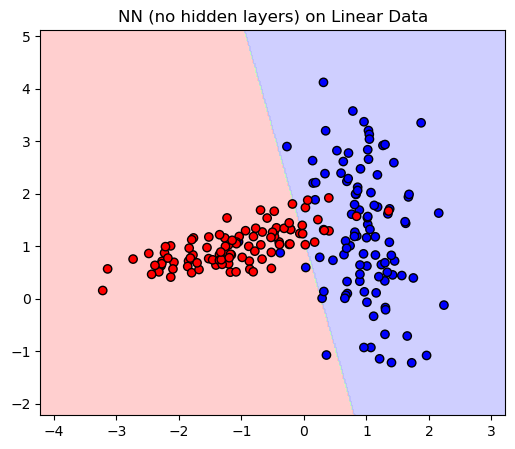

Classification (Nonlinear NN) Accuracy: 0.9666666666666667


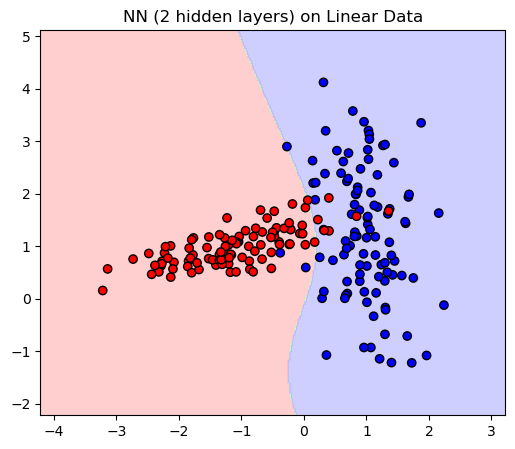

In [12]:
X, y = make_classification(n_samples=200, n_features=2, n_redundant=0,
                           n_informative=2, n_clusters_per_class=1,
                           random_state=0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Simple neural network (linear)
mlp_linear = MLPClassifier(hidden_layer_sizes=(), activation='logistic', max_iter=2000, random_state=0)
mlp_linear.fit(X_train, y_train)

print("Classification (Linear) Accuracy:", mlp_linear.score(X_test, y_test))
plot_decision_boundary(mlp_linear, X, y, "NN (no hidden layers) on Linear Data")

# Add hidden layers
mlp_hidden = MLPClassifier(hidden_layer_sizes=(10, 10), activation='tanh', max_iter=2000, random_state=0)
mlp_hidden.fit(X_train, y_train)

print("Classification (Nonlinear NN) Accuracy:", mlp_hidden.score(X_test, y_test))
plot_decision_boundary(mlp_hidden, X, y, "NN (2 hidden layers) on Linear Data")
